<a href="https://colab.research.google.com/github/Pritishcoder07/Predictive-Model/blob/main/Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('predictive_maintenance.csv')

In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
df.shape

(10000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


In [ ]:
df.to_csv("cleaned_data.csv", index=False)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
dff=df[['Type','Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Target']]

In [ ]:
dff.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [ ]:
dff.shape

(10000, 7)

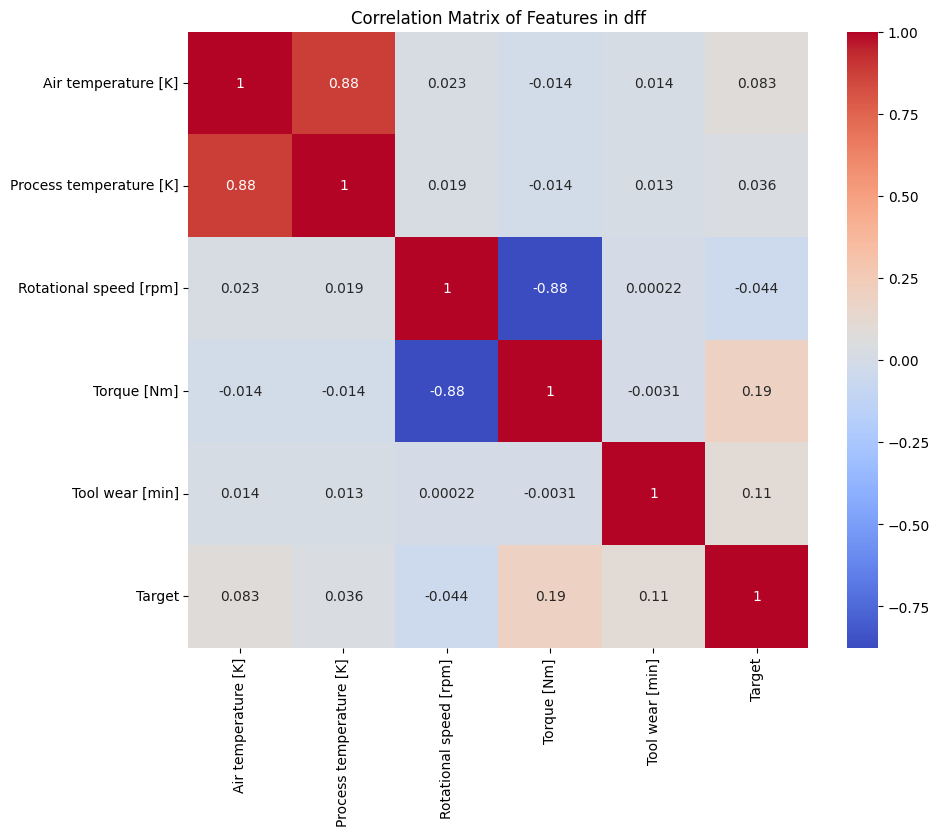

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns from dff for correlation calculation
numeric_dff = dff.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_dff.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features in dff')
plt.show()

In [ ]:
df["Temp_diff"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

In [ ]:
dff.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [ ]:
df['Temp_diff']

,Temp_diff
0,10.5
1,10.5
2,10.4
3,10.4
4,10.5
...,...
9995,9.6
9996,9.5
9997,9.6
9998,9.7


In [ ]:
dff=df[['Type','Temp_diff','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']]

In [ ]:
dff.head()

,Type,Temp_diff,Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,10.5,1551,42.8,0
1,L,10.5,1408,46.3,3
2,L,10.4,1498,49.4,5
3,L,10.4,1433,39.5,7
4,L,10.5,1408,40.0,9


In [ ]:
dff.Type

,Type
0,M
1,L
2,L
3,L
4,L
...,...
9995,M
9996,H
9997,M
9998,H


In [ ]:
df["Type"].unique()

array(['M', 'L', 'H'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dff["Type"] = le.fit_transform(dff["Type"])

/tmp/ipykernel_4438/2870957462.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff["Type"] = le.fit_transform(dff["Type"])


In [ ]:
dff["Type"].unique()

array([2, 1, 0])

In [ ]:
dff.head()

,Type,Temp_diff,Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,2,10.5,1551,42.8,0
1,1,10.5,1408,46.3,3
2,1,10.4,1498,49.4,5
3,1,10.4,1433,39.5,7
4,1,10.5,1408,40.0,9


In [ ]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print(mapping)

{'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}


In [ ]:

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



In [ ]:
X = dff
y = df["Target"]

In [ ]:
X.columns = (
    X.columns
    .str.replace(r' \[.*\]', '', regex=True)
    .str.replace(' ', '_', regex=True)
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.9865


In [ ]:
# Training accuracy
train_acc = model.score(X_train, y_train)

# Testing accuracy
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.996375
Test Accuracy: 0.9865


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[1930    9]
 [  18   43]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.83      0.70      0.76        61

    accuracy                           0.99      2000
   macro avg       0.91      0.85      0.88      2000
weighted avg       0.99      0.99      0.99      2000



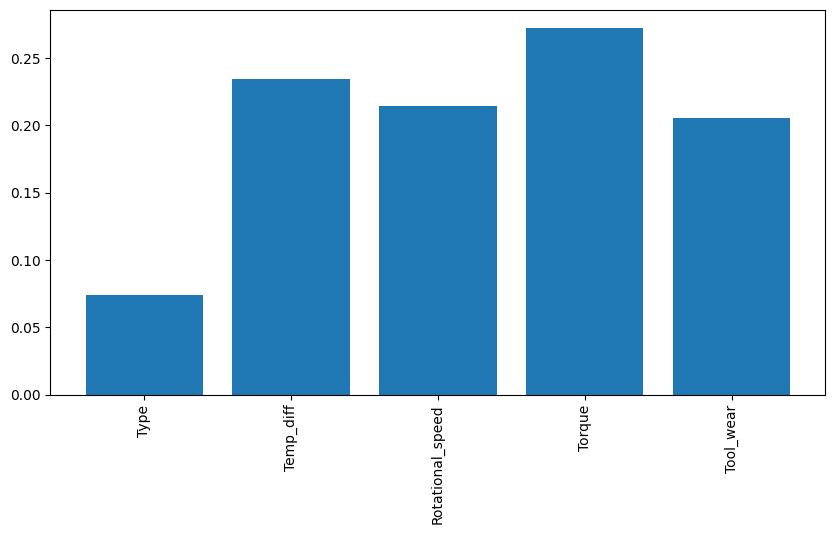

In [ ]:
importance = model.feature_importances_

plt.figure(figsize=(10,5))

plt.bar(X.columns, importance)

plt.xticks(rotation=90)

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
X = dff
y = df["Target"]

In [ ]:
X.columns = (
    X.columns
    .str.replace(r' \[.*\]', '', regex=True)
    .str.replace(' ', '_', regex=True)
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Re-run train_test_split to ensure X_train and y_train are updated from the global X and y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred)
print("Random Forest Model Accuracy:", accuracy)

Random Forest Model Accuracy: 0.987


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[1932    7]
 [  19   42]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.86      0.69      0.76        61

    accuracy                           0.99      2000
   macro avg       0.92      0.84      0.88      2000
weighted avg       0.99      0.99      0.99      2000



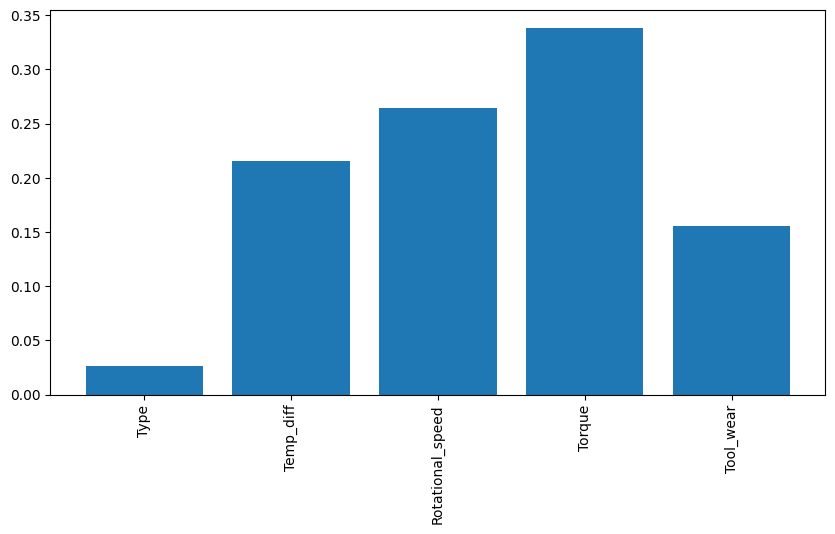

In [ ]:
importance = model.feature_importances_

plt.figure(figsize=(10,5))

plt.bar(X.columns, importance)

plt.xticks(rotation=90)

plt.show()

In [ ]:
# Training accuracy
train_acc = model.score(X_train, y_train)

# Testing accuracy
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.987
